# I. Tiền xử lý dữ liệu

## 1. Làm sạch, resize, crop, lưu ảnh

**Thao tác:** Duyệt toàn bộ tập ảnh train/test, tự động cắt vùng chứa vật thể chính (crop), chuẩn hoá kích thước về 128×128 pixel, và lưu ảnh đã xử lý vào thư mục `data/cleaned`.

In [1]:
import os
import cv2
import imutils
from tqdm import tqdm
import numpy as np

# HÀM CẮT ẢNH THEO VÙNG CHÍNH
def crop_img(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)
    cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutils.grab_contours(cnts)
    c = max(cnts, key=cv2.contourArea)
    extLeft = tuple(c[c[:, :, 0].argmin()][0])
    extRight = tuple(c[c[:, :, 0].argmax()][0])
    extTop = tuple(c[c[:, :, 1].argmin()][0])
    extBot = tuple(c[c[:, :, 1].argmax()][0])
    return img[extTop[1]:extBot[1], extLeft[0]:extRight[0]].copy()

# CHUẨN BỊ ĐƯỜNG DẪN VÀ THAM SỐ XỬ LÝ
BASE_DIR = os.getcwd()
training_raw = os.path.join(BASE_DIR, "data", "raw", "Training")
testing_raw = os.path.join(BASE_DIR, "data", "raw", "Testing")
cleaned_path = os.path.join(BASE_DIR, "data", "cleaned")
IMG_SIZE = 128

print(f"Thư mục dữ liệu gốc: {os.path.join(BASE_DIR, 'data', 'raw')}")
print(f"Thư mục lưu dữ liệu đã xử lý: {cleaned_path}")

def process_and_save(dataset, name):
    print(f"\nĐang xử lý tập {name}...")
    for label_dir in os.listdir(dataset):
        path = os.path.join(dataset, label_dir)
        save_path = os.path.join(cleaned_path, name, label_dir)
        
        if os.path.exists(save_path) and len(os.listdir(save_path)) > 0:
            # print(f"Bỏ qua {name}/{label_dir} (đã có dữ liệu).")
            continue

        os.makedirs(save_path, exist_ok=True)
        for img_file in tqdm(os.listdir(path), desc=f"{name}/{label_dir}"):
            image_path = os.path.join(path, img_file)
            image = cv2.imread(image_path)
            if image is None: continue
            try:
                cropped = crop_img(image)
                resized = cv2.resize(cropped, (IMG_SIZE, IMG_SIZE))
                cv2.imwrite(os.path.join(save_path, img_file), resized)
            except Exception as e:
                print(f"Lỗi xử lý ảnh {img_file}: {e}")

process_and_save(training_raw, "Training")
process_and_save(testing_raw, "Testing")
print("\nHoàn tất tiền xử lý ảnh!")

Thư mục dữ liệu gốc: D:\NAM BA\Semester 1\ML\Lab\project_ml\data\raw
Thư mục lưu dữ liệu đã xử lý: D:\NAM BA\Semester 1\ML\Lab\project_ml\data\cleaned

Đang xử lý tập Training...

Đang xử lý tập Testing...

Hoàn tất tiền xử lý ảnh!


# II. Phân loại góc chụp & Tái cấu trúc dữ liệu

## 1. Đọc toàn bộ dữ liệu, trích xuất HOG

Đọc tất cả ảnh từ `data/cleaned`, gán nhãn khối u, sau đó trích xuất đặc trưng HOG cho toàn bộ 7023 ảnh.

In [2]:
from sklearn.preprocessing import LabelEncoder
from skimage.feature import hog
import pandas as pd

def load_all_cleaned_images(base_cleaned_path):
    all_images = []
    all_labels = []
    all_filenames = []
    all_splits = [] # Train hay Test

    for split in ["Training", "Testing"]:
        split_path = os.path.join(base_cleaned_path, split)
        for label in os.listdir(split_path):
            folder_path = os.path.join(split_path, label)
            for filename in tqdm(os.listdir(folder_path), desc=f"Đọc {split}/{label}"):
                img_path = os.path.join(folder_path, filename)
                img = cv2.imread(img_path)
                if img is not None:
                    all_images.append(img)
                    all_labels.append(label)
                    all_filenames.append(filename)
                    all_splits.append(split)
                    
    return np.array(all_images), np.array(all_labels), all_filenames, np.array(all_splits)

def extract_hog_features(images):
    hog_features = []
    images_float = images.astype('float32') / 255.0
    for img in tqdm(images_float, desc="Trích xuất HOG"):
        gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_BGR2GRAY)
        feat = hog(gray, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2),
                   block_norm='L2-Hys', transform_sqrt=True, feature_vector=True)
        hog_features.append(feat)
    return np.array(hog_features)

# Đọc tất cả ảnh và nhãn
all_images, all_tumor_labels, all_filenames, all_splits = load_all_cleaned_images(cleaned_path)

# Mã hóa nhãn khối u thành số
tumor_label_encoder = LabelEncoder()
all_tumor_labels_encoded = tumor_label_encoder.fit_transform(all_tumor_labels)

# Trích xuất HOG cho tất cả ảnh
all_hog_features = extract_hog_features(all_images)

print(f"\nTổng số ảnh: {len(all_images)}")
print(f"Kích thước ma trận HOG: {all_hog_features.shape}")
print(f"Các lớp khối u: {tumor_label_encoder.classes_}")

Trích xuất HOG: 100%|██████████| 7023/7023 [00:47<00:00, 148.56it/s]



Tổng số ảnh: 7023
Kích thước ma trận HOG: (7023, 8100)
Các lớp khối u: ['glioma' 'meningioma' 'notumor' 'pituitary']


## 2. Phân cụm góc chụp bằng K-Means

Sử dụng K-Means để tự động nhóm các ảnh có đặc trưng HOG giống nhau vào 3 cụm. Sau đó, chúng ta sẽ kiểm tra và gán nhãn `axial`, `coronal`, `sagittal` cho từng cụm.

Bắt đầu phân cụm K-Means...
Phân cụm hoàn tất!

!!! ĐANG HIỂN THỊ ẢNH ĐỂ GÁN NHÃN THỦ CÔNG !!!
!!! BẠN CẦN ĐÓNG CỬA SỔ ẢNH NÀY ĐỂ CODE CHẠY TIẾP PHẦN VẼ BIỂU ĐỒ !!!


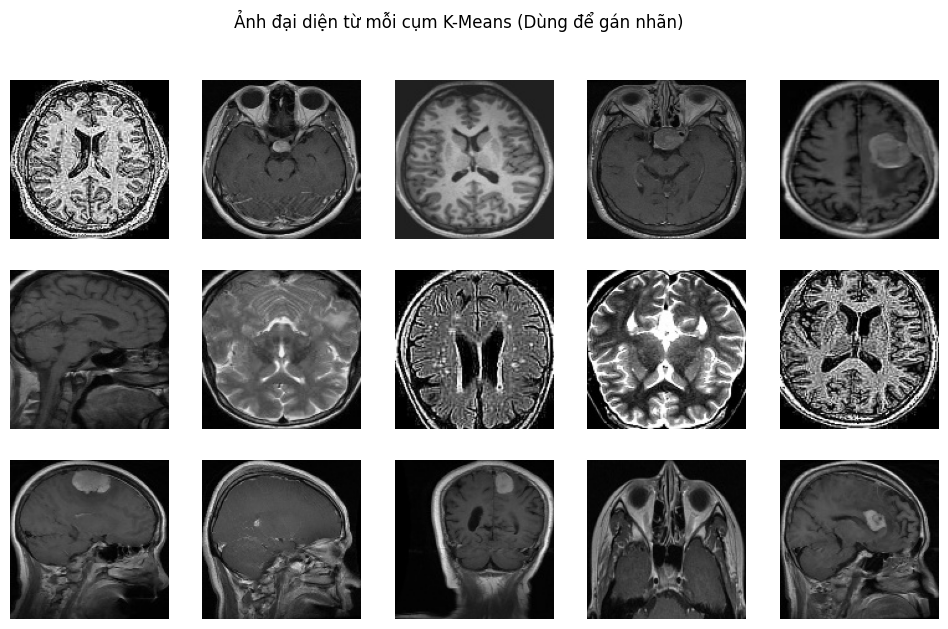


Gán nhãn góc chụp hoàn tất.
Các góc chụp tìm thấy: ['axial' 'coronal' 'sagittal']

Đang vẽ Biểu đồ 1: Phân bổ số lượng ảnh...


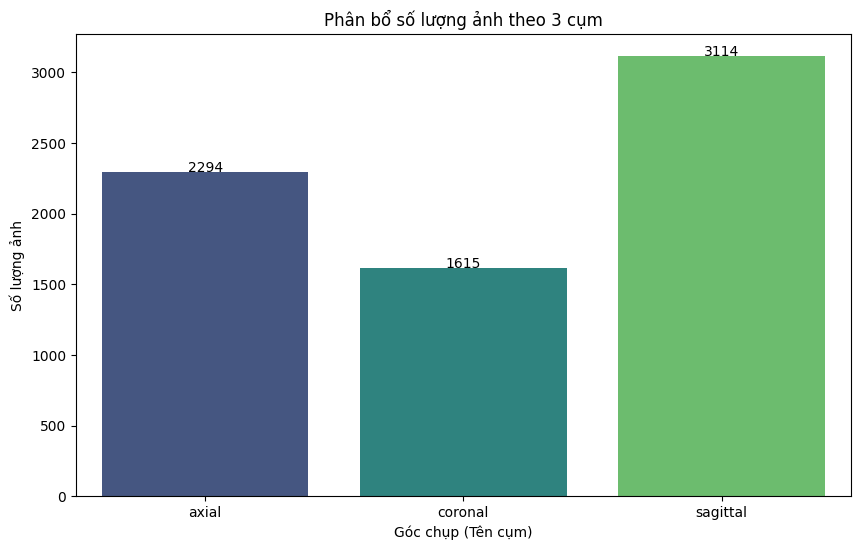


Đang vẽ Biểu đồ 2: Phân tách cụm (Dùng PCA)...
Hoàn tất! Đang hiển thị biểu đồ cuối cùng.


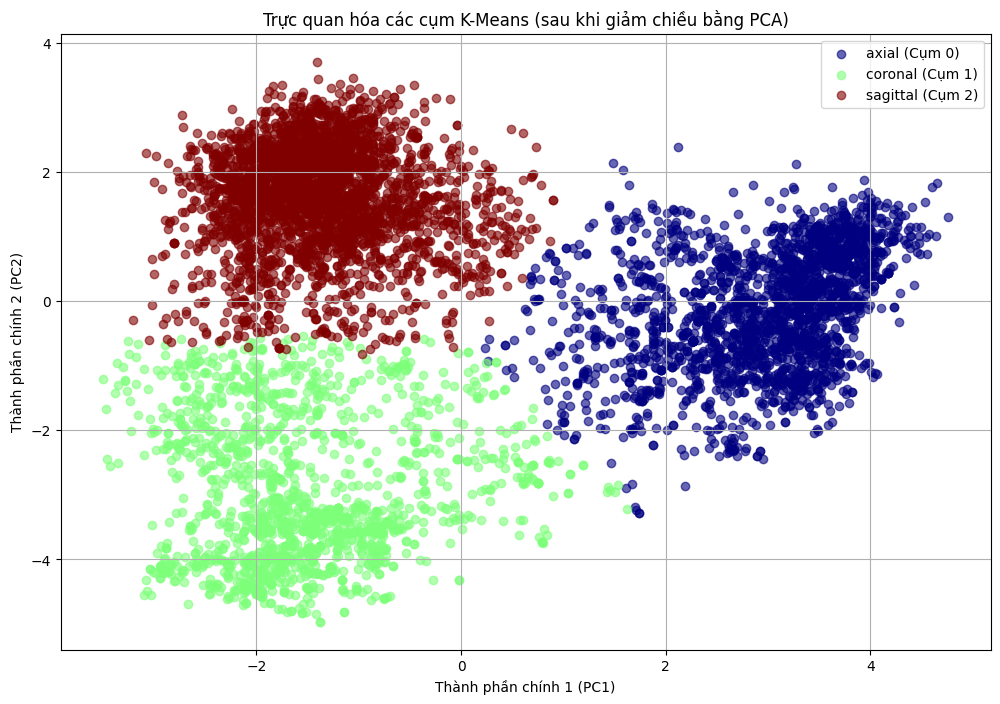

In [6]:
import numpy as np # Giả sử bạn đã import
import cv2 # Giả sử bạn đã import
from sklearn.preprocessing import LabelEncoder # Giả sử bạn đã import
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# =====================================================================
# Giả sử các biến all_hog_features và all_images đã tồn tại ở đây
# =====================================================================

N_CLUSTERS = 3
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
print("Bắt đầu phân cụm K-Means...")
all_angle_clusters = kmeans.fit_predict(all_hog_features)
print("Phân cụm hoàn tất!")

# Hiển thị một vài ảnh từ mỗi cụm để gán nhãn
fig, axes = plt.subplots(N_CLUSTERS, 5, figsize=(12, 7))
for i in range(N_CLUSTERS):
    cluster_indices = np.where(all_angle_clusters == i)[0]

    # Đảm bảo có đủ mẫu để hiển thị
    if len(cluster_indices) >= 5:
        sample_indices = np.random.choice(cluster_indices, 5, replace=False)
    else:
        # Nếu không đủ 5 mẫu, lấy tất cả
        sample_indices = np.random.choice(cluster_indices, len(cluster_indices), replace=False)

    axes[i, 0].set_ylabel(f'Cụm {i}')

    for j, img_idx in enumerate(sample_indices):
        axes[i, j].imshow(cv2.cvtColor(all_images[img_idx], cv2.COLOR_BGR2RGB))
        axes[i, j].axis('off')

plt.suptitle('Ảnh đại diện từ mỗi cụm K-Means (Dùng để gán nhãn)')
print("\n!!! ĐANG HIỂN THỊ ẢNH ĐỂ GÁN NHÃN THỦ CÔNG !!!")
print("!!! BẠN CẦN ĐÓNG CỬA SỔ ẢNH NÀY ĐỂ CODE CHẠY TIẾP PHẦN VẼ BIỂU ĐỒ !!!")
plt.show() # Lệnh này sẽ dừng code cho đến khi bạn đóng cửa sổ ảnh

# =====================================================================
## 3. GÁN NHÃN THỦ CÔNG (Code gốc của bạn)
# =====================================================================

cluster_to_angle_map = {
    0: 'axial',      # Thay đổi nếu cần
    1: 'coronal',    # Thay đổi nếu cần
    2: 'sagittal'    # Thay đổi nếu cần
}

all_angle_labels = np.array([cluster_to_angle_map[c] for c in all_angle_clusters])
angle_label_encoder = LabelEncoder()
all_angle_labels_encoded = angle_label_encoder.fit_transform(all_angle_labels)

print("\nGán nhãn góc chụp hoàn tất.")
print(f"Các góc chụp tìm thấy: {angle_label_encoder.classes_}")

# =====================================================================
## 4. TRỰC QUAN HÓA 1: BIỂU ĐỒ PHÂN BỔ CỤM
# =====================================================================

print("\nĐang vẽ Biểu đồ 1: Phân bổ số lượng ảnh...")
# Đếm số lượng ảnh trong mỗi cụm
cluster_ids, counts = np.unique(all_angle_clusters, return_counts=True)

# Lấy tên nhãn (axial, coronal,...) từ map của bạn
labels = [cluster_to_angle_map.get(id, f'Cụm {id}') for id in cluster_ids]

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
# --- ĐÃ SỬA DÒNG NÀY ---
# Thêm hue=labels và legend=False theo yêu cầu của Seaborn
sns.barplot(x=labels, y=counts, hue=labels, palette='viridis', legend=False)
# --- KẾT THÚC SỬA ---
plt.title(f'Phân bổ số lượng ảnh theo {N_CLUSTERS} cụm')
plt.xlabel('Góc chụp (Tên cụm)')
plt.ylabel('Số lượng ảnh')

# Hiển thị số lượng trên đỉnh mỗi cột
for index, value in enumerate(counts):
    plt.text(index, value + 0.5, str(value), ha='center')

plt.show() # Hiển thị biểu đồ thứ 2

# =====================================================================
## 5. TRỰC QUAN HÓA 2: BIỂU ĐỒ PHÂN TÁCH CỤM (PCA)
# =====================================================================

print("\nĐang vẽ Biểu đồ 2: Phân tách cụm (Dùng PCA)...")

# 1. Giảm chiều dữ liệu HOG xuống 2 thành phần chính (2D)
pca = PCA(n_components=2, random_state=42)
features_2d = pca.fit_transform(all_hog_features)

# 2. Vẽ biểu đồ phân tán (scatter plot)
plt.figure(figsize=(12, 8))

# --- ĐÃ SỬA DÒNG NÀY ---
# Thay vì plt.cm.get_cmap, dùng plt.get_cmap
# và tạo ra một danh sách các màu sắc
colors = plt.get_cmap('jet')(np.linspace(0, 1, N_CLUSTERS))
# --- KẾT THÚC SỬA ---

for i in range(N_CLUSTERS):
    # Lọc ra các điểm thuộc cụm i
    cluster_points = features_2d[all_angle_clusters == i]

    # Lấy tên nhãn
    label_name = cluster_to_angle_map.get(i, f'Cụm {i}')

    # Vẽ các điểm của cụm i
    plt.scatter(cluster_points[:, 0],  # Trục X (PC1)
                cluster_points[:, 1],  # Trục Y (PC2)
                color=colors[i],      # Sửa: dùng chỉ số [i]
                label=f'{label_name} (Cụm {i})',
                alpha=0.6)

plt.title('Trực quan hóa các cụm K-Means (sau khi giảm chiều bằng PCA)')
plt.xlabel('Thành phần chính 1 (PC1)')
plt.ylabel('Thành phần chính 2 (PC2)')
plt.legend()
plt.grid(True)

print("Hoàn tất! Đang hiển thị biểu đồ cuối cùng.")
plt.show() # Hiển thị biểu đồ cuối cùng

## 3. Tái cấu trúc dữ liệu theo góc chụp

Chia bộ dữ liệu HOG và nhãn thành các dictionary, mỗi key là một góc chụp.

In [7]:
data_by_angle = {angle: {} for angle in angle_label_encoder.classes_}

for angle in angle_label_encoder.classes_:
    # Lọc ra các chỉ số (indices) của ảnh thuộc góc chụp hiện tại
    angle_mask = (all_angle_labels == angle)
    
    # Lấy HOG features và nhãn khối u tương ứng
    X_hog_angle = all_hog_features[angle_mask]
    y_tumor_angle = all_tumor_labels_encoded[angle_mask]
    splits_angle = all_splits[angle_mask]
    
    # Chia thành tập train và test dựa trên split đã có
    train_mask = (splits_angle == 'Training')
    test_mask = (splits_angle == 'Testing')
    
    data_by_angle[angle]['X_train_hog'] = X_hog_angle[train_mask]
    data_by_angle[angle]['y_train_encoded'] = y_tumor_angle[train_mask]
    data_by_angle[angle]['X_test_hog'] = X_hog_angle[test_mask]
    data_by_angle[angle]['y_test_encoded'] = y_tumor_angle[test_mask]
    
    print(f"Góc chụp '{angle}':")
    print(f"  - Train: {len(data_by_angle[angle]['X_train_hog'])} mẫu")
    print(f"  - Test:  {len(data_by_angle[angle]['X_test_hog'])} mẫu")

Góc chụp 'axial':
  - Train: 1791 mẫu
  - Test:  503 mẫu
Góc chụp 'coronal':
  - Train: 1305 mẫu
  - Test:  310 mẫu
Góc chụp 'sagittal':
  - Train: 2616 mẫu
  - Test:  498 mẫu


# III. Huấn luyện các mô hình trên từng góc chụp

## 1. Huấn luyện các mô hình

Bây giờ, chúng ta sẽ lặp qua từng góc chụp. Với mỗi góc, ta áp dụng PCA và LDA riêng, sau đó huấn luyện và đánh giá 2 mô hình Naive Bayes và Logistic Regression.

In [8]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report # Đảm bảo đã import
import warnings
import pandas as pd

warnings.filterwarnings('ignore')

# Lưu kết quả và các mô hình đã huấn luyện
results = {}
models = {}

# Lặp qua từng góc chụp
for angle, data in data_by_angle.items():
    print("\n" + "="*40)
    print(f"HUẤN LUYỆN CHO GÓC CHỤP: {angle.upper()}")
    print("="*40)

    # Lấy dữ liệu của góc chụp hiện tại
    X_train_hog = data['X_train_hog']
    y_train_encoded = data['y_train_encoded']
    X_test_hog = data['X_test_hog']
    y_test_encoded = data['y_test_encoded']
    
    # Bỏ qua nếu không có đủ dữ liệu test cho góc chụp này
    if len(X_test_hog) == 0:
        print(f"Bỏ qua góc chụp '{angle}' vì không có dữ liệu test.")
        continue
    
    # Khởi tạo models và dict lưu kết quả cho góc chụp này
    results[angle] = {}
    models[angle] = {}
    
    # --- 1. HUẤN LUYỆN VỚI PCA ---
    print("\n--- Áp dụng PCA ---")
    pca = PCA(n_components=0.9)
    X_train_pca = pca.fit_transform(X_train_hog)
    X_test_pca = pca.transform(X_test_hog)
    models[angle]['pca'] = pca
    print(f"Số chiều sau PCA: {X_train_pca.shape[1]}")

    # a) Naive Bayes + PCA
    nb_pca = GaussianNB()
    nb_pca.fit(X_train_pca, y_train_encoded)
    y_pred = nb_pca.predict(X_test_pca)
    acc = accuracy_score(y_test_encoded, y_pred)
    results[angle]['Naive Bayes + PCA'] = acc
    models[angle]['nb_pca'] = nb_pca
    print(f"\nĐộ chính xác Naive Bayes + PCA: {acc:.4f}")
    # <<< THÊM VÀO ĐÂY: In báo cáo chi tiết
    print("Classification Report (Naive Bayes + PCA):")
    print(classification_report(y_test_encoded, y_pred, target_names=tumor_label_encoder.classes_))

    # b) Logistic Regression + PCA
    lr_pca = LogisticRegression(max_iter=1000)
    lr_pca.fit(X_train_pca, y_train_encoded)
    y_pred = lr_pca.predict(X_test_pca)
    acc = accuracy_score(y_test_encoded, y_pred)
    results[angle]['Logistic Reg + PCA'] = acc
    models[angle]['lr_pca'] = lr_pca
    print(f"\nĐộ chính xác Logistic Reg + PCA: {acc:.4f}")
    # <<< THÊM VÀO ĐÂY: In báo cáo chi tiết
    print("Classification Report (Logistic Reg + PCA):")
    print(classification_report(y_test_encoded, y_pred, target_names=tumor_label_encoder.classes_))

    # --- 2. HUẤN LUYỆN VỚI LDA ---
    # Bỏ qua nếu số mẫu ít hơn số chiều, không đủ để fit LDA
    if X_train_hog.shape[0] < (len(np.unique(y_train_encoded)) - 1):
        print(f"\nBỏ qua LDA cho góc '{angle}' vì số mẫu train quá ít.")
        continue

    print("\n--- Áp dụng LDA ---")
    num_classes = len(np.unique(y_train_encoded))
    # Đảm bảo n_components không lớn hơn số mẫu
    n_components_lda = min(num_classes - 1, X_train_hog.shape[0] - 1)
    
    if n_components_lda < 1:
        print(f"Không thể áp dụng LDA với n_components < 1.")
        continue
        
    lda = LinearDiscriminantAnalysis(n_components=n_components_lda)
    X_train_lda = lda.fit_transform(X_train_hog, y_train_encoded)
    X_test_lda = lda.transform(X_test_hog)
    models[angle]['lda'] = lda
    print(f"Số chiều sau LDA: {X_train_lda.shape[1]}")
    
    # a) Naive Bayes + LDA
    nb_lda = GaussianNB()
    nb_lda.fit(X_train_lda, y_train_encoded)
    y_pred = nb_lda.predict(X_test_lda)
    acc = accuracy_score(y_test_encoded, y_pred)
    results[angle]['Naive Bayes + LDA'] = acc
    models[angle]['nb_lda'] = nb_lda
    print(f"\nĐộ chính xác Naive Bayes + LDA: {acc:.4f}")
    # <<< THÊM VÀO ĐÂY: In báo cáo chi tiết
    print("Classification Report (Naive Bayes + LDA):")
    print(classification_report(y_test_encoded, y_pred, target_names=tumor_label_encoder.classes_))

    # b) Logistic Regression + LDA
    lr_lda = LogisticRegression(max_iter=1000)
    lr_lda.fit(X_train_lda, y_train_encoded)
    y_pred = lr_lda.predict(X_test_lda)
    acc = accuracy_score(y_test_encoded, y_pred)
    results[angle]['Logistic Reg + LDA'] = acc
    models[angle]['lr_lda'] = lr_lda
    print(f"\nĐộ chính xác Logistic Reg + LDA: {acc:.4f}")
    # <<< THÊM VÀO ĐÂY: In báo cáo chi tiết
    print("Classification Report (Logistic Reg + LDA):")
    print(classification_report(y_test_encoded, y_pred, target_names=tumor_label_encoder.classes_))


HUẤN LUYỆN CHO GÓC CHỤP: AXIAL

--- Áp dụng PCA ---
Số chiều sau PCA: 722

Độ chính xác Naive Bayes + PCA: 0.5070
Classification Report (Naive Bayes + PCA):
              precision    recall  f1-score   support

      glioma       0.39      0.07      0.12       100
  meningioma       0.87      0.32      0.46       123
     notumor       0.50      0.85      0.63       161
   pituitary       0.43      0.61      0.50       119

    accuracy                           0.51       503
   macro avg       0.55      0.46      0.43       503
weighted avg       0.55      0.51      0.46       503


Độ chính xác Logistic Reg + PCA: 0.9066
Classification Report (Logistic Reg + PCA):
              precision    recall  f1-score   support

      glioma       0.88      0.80      0.84       100
  meningioma       0.87      0.85      0.86       123
     notumor       0.96      0.99      0.98       161
   pituitary       0.90      0.94      0.92       119

    accuracy                           0.91       

## 2. Tổng kết và so sánh kết quả


In [9]:
results_df = pd.DataFrame(results).T
print("BẢNG TỔNG KẾT ĐỘ CHÍNH XÁC (ACCURACY)")
results_df

BẢNG TỔNG KẾT ĐỘ CHÍNH XÁC (ACCURACY)


,Naive Bayes + PCA,Logistic Reg + PCA,Naive Bayes + LDA,Logistic Reg + LDA
axial,0.506958,0.906561,0.862823,0.860835
coronal,0.729032,0.951613,0.832258,0.812903
sagittal,0.417671,0.859438,0.797189,0.797189


# IV. Xây dựng Pipeline dự đoán 2 bước

## 1. Huấn luyện mô hình phân loại góc chụp

Sử dụng toàn bộ dữ liệu HOG và nhãn góc chụp đã tạo để huấn luyện một mô hình chuyên phân loại góc chụp.

In [10]:
from sklearn.model_selection import train_test_split

print("Chuẩn bị dữ liệu cho mô hình phân loại góc chụp...")
# Chia dữ liệu HOG và nhãn góc chụp thành tập train/test
X_train_angle, X_test_angle, y_train_angle, y_test_angle = train_test_split(
    all_hog_features, all_angle_labels_encoded, test_size=0.2, random_state=42, stratify=all_angle_labels_encoded
)

print("Huấn luyện mô hình Logistic Regression để phân loại góc chụp...")
angle_classifier = LogisticRegression(max_iter=1000)
angle_classifier.fit(X_train_angle, y_train_angle)

acc_angle = angle_classifier.score(X_test_angle, y_test_angle)
print(f"Độ chính xác của mô hình phân loại góc chụp: {acc_angle:.4f}")

# Lưu lại mô hình này để dùng trong pipeline
models['angle_classifier'] = angle_classifier

Chuẩn bị dữ liệu cho mô hình phân loại góc chụp...
Huấn luyện mô hình Logistic Regression để phân loại góc chụp...
Độ chính xác của mô hình phân loại góc chụp: 0.9957


## 2. Tạo hàm dự đoán cuối cùng

Hàm này sẽ thực hiện toàn bộ quy trình: nhận ảnh -> xử lý -> trích xuất HOG -> dự đoán góc chụp -> chọn mô hình phù hợp -> dự đoán loại khối u.

In [11]:
def predict_image(image_path, models, angle_label_encoder, tumor_label_encoder):
    # 1. Đọc và tiền xử lý ảnh
    img = cv2.imread(image_path)
    if img is None:
        return "Lỗi: Không thể đọc ảnh"
    try:
        cropped = crop_img(img)
        resized = cv2.resize(cropped, (IMG_SIZE, IMG_SIZE))
    except:
        return "Lỗi: Không thể crop/resize ảnh"
    
    # 2. Trích xuất đặc trưng HOG
    hog_feature = extract_hog_features(np.array([resized]))

    # 3. Dự đoán góc chụp
    angle_classifier = models['angle_classifier']
    predicted_angle_encoded = angle_classifier.predict(hog_feature)[0]
    predicted_angle = angle_label_encoder.inverse_transform([predicted_angle_encoded])[0]
    
    # 4. Chọn mô hình phù hợp và dự đoán khối u
    # Giả sử ta chọn mô hình tốt nhất cho mỗi góc chụp (ví dụ Logistic Regression + PCA)
    # Bạn có thể thay đổi logic này để chọn mô hình khác
    best_model_key = 'lr_pca' # Thay đổi nếu cần, ví dụ 'nb_lda'
    
    reducer = models[predicted_angle]['pca'] # Hoặc 'lda'
    classifier = models[predicted_angle][best_model_key]
    
    # Áp dụng giảm chiều
    hog_feature_reduced = reducer.transform(hog_feature)
    
    # Dự đoán khối u
    predicted_tumor_encoded = classifier.predict(hog_feature_reduced)[0]
    predicted_tumor = tumor_label_encoder.inverse_transform([predicted_tumor_encoded])[0]
    
    return f"Góc chụp dự đoán: {predicted_angle}, Loại khối u dự đoán: {predicted_tumor}"

print("Hàm `predict_image` đã sẵn sàng.")

Hàm `predict_image` đã sẵn sàng.


## 3. Thử nghiệm Pipeline

Lấy một ảnh ngẫu nhiên từ tập test để kiểm tra.

In [12]:
# Lấy một ảnh ví dụ từ tập test
cnt = 0
tong = 0
for i in range(10, 305):
    tong += 1
    example_image_path = ''
    if (i < 100): example_image_path = os.path.join(testing_raw, 'meningioma', 'Te-me_00' + str(i) + '.jpg')
    else: example_image_path = os.path.join(testing_raw, 'meningioma', 'Te-me_0' + str(i) + '.jpg')
    prediction = predict_image(example_image_path, models, angle_label_encoder, tumor_label_encoder)
    # print(f"Với ảnh: {example_image_path}")
    # print(f"Kết quả dự đoán: {prediction}")
    if 'meningioma' in prediction:
        cnt+=1
    

print('accuracy =', cnt / tong)

# Thực hiện dự đoán
# prediction = predict_image(example_image_path, models, angle_label_encoder, tumor_label_encoder)

# print(f"Với ảnh: {example_image_path}")
# print(f"Kết quả dự đoán: {prediction}")

Trích xuất HOG: 100%|██████████| 1/1 [00:00<00:00, 116.80it/s]

accuracy = 0.8711864406779661


# V. Đánh giá Pipeline Toàn diện trên Tập Test

In [15]:
from sklearn.metrics import accuracy_score, classification_report
from tqdm import tqdm
import numpy as np

print("Bắt đầu đánh giá pipeline 2 bước trên toàn bộ tập test...")

# 1. Tái tạo lại tập test hoàn chỉnh
test_mask = (all_splits == 'Testing')
X_test_full_hog = all_hog_features[test_mask]
y_test_true_tumor = all_tumor_labels_encoded[test_mask]

# 2. Chọn tổ hợp mô hình tốt nhất
REDUCER_KEY = 'pca'
CLASSIFIER_KEY = 'lr_pca'
print(f"Sử dụng tổ hợp mô hình: {CLASSIFIER_KEY.replace('_', ' + ').upper()}")

# 3. Chạy pipeline dự đoán trên từng mẫu của tập test
pipeline_test_predictions = []
angle_model = models['angle_classifier']

for hog_feature in tqdm(X_test_full_hog, desc="Đang dự đoán trên tập test"):
    hog_feature_reshaped = hog_feature.reshape(1, -1)

    # --- Bước A: Dự đoán góc chụp ---
    predicted_angle_encoded = angle_model.predict(hog_feature_reshaped)[0]
    predicted_angle_name = angle_label_encoder.inverse_transform([predicted_angle_encoded])[0]

    # --- Bước B & C: Chọn mô hình và áp dụng giảm chiều ---
    reducer = models[predicted_angle_name][REDUCER_KEY]
    classifier = models[predicted_angle_name][CLASSIFIER_KEY]

    feature_reduced = reducer.transform(hog_feature_reshaped)

    # --- Bước D: Dự đoán loại khối u ---
    predicted_tumor_encoded = classifier.predict(feature_reduced)[0]
    pipeline_test_predictions.append(predicted_tumor_encoded)

pipeline_test_predictions = np.array(pipeline_test_predictions)

# 4. Đánh giá kết quả cuối cùng (TẬP TEST)
test_accuracy = accuracy_score(y_test_true_tumor, pipeline_test_predictions) # <-- Đã đổi tên
print("\n" + "="*40)
print("KẾT QUẢ ĐÁNH GIÁ PIPELINE (TẬP TEST)")
print("="*40)
print(f"\nĐộ chính xác tổng thể (Test): {test_accuracy:.4f}") # <-- Đã đổi tên

print("\nBáo cáo chi tiết (Test):")
print(classification_report(y_test_true_tumor, pipeline_test_predictions, target_names=tumor_label_encoder.classes_))

Bắt đầu đánh giá pipeline 2 bước trên toàn bộ tập test...
Sử dụng tổ hợp mô hình: LR + PCA


Đang dự đoán trên tập test: 100%|██████████| 1311/1311 [00:16<00:00, 81.37it/s] 


KẾT QUẢ ĐÁNH GIÁ PIPELINE (TẬP TEST)

Độ chính xác tổng thể (Test): 0.8986

Báo cáo chi tiết (Test):
              precision    recall  f1-score   support

      glioma       0.86      0.78      0.82       300
  meningioma       0.83      0.84      0.84       306
     notumor       0.97      1.00      0.98       405
   pituitary       0.91      0.94      0.92       300

    accuracy                           0.90      1311
   macro avg       0.89      0.89      0.89      1311
weighted avg       0.90      0.90      0.90      1311



In [16]:
# =====================================================================
## PHÂN TÍCH OVERFIT: ĐÁNH GIÁ TƯƠNG TỰ TRÊN TẬP TRAIN
# =====================================================================
print("\n" + "="*40)
print("PHÂN TÍCH OVERFIT: ĐÁNH GIÁ TRÊN TẬP TRAIN")
print("="*40)

# 1. Tái tạo lại tập train hoàn chỉnh
try:
    train_mask = (all_splits == 'Training')
    X_train_full_hog = all_hog_features[train_mask]
    y_train_true_tumor = all_tumor_labels_encoded[train_mask]
except NameError as e:
    print(f"Lỗi: Không tìm thấy các biến toàn cục (ví dụ: all_splits, all_hog_features).")
    print(f"Chi tiết lỗi: {e}")
    # Dừng ở đây nếu không có dữ liệu
    exit()

if len(X_train_full_hog) == 0:
    print("Lỗi: Không tìm thấy mẫu nào trong tập train. Không thể đánh giá overfit.")
else:
    print(f"Tìm thấy {len(X_train_full_hog)} mẫu train để đánh giá.")

    # 2. Chạy pipeline dự đoán trên từng mẫu của tập train
    pipeline_train_predictions = []
    # (Sử dụng lại angle_model, REDUCER_KEY, CLASSIFIER_KEY từ bước trên)

    for hog_feature in tqdm(X_train_full_hog, desc="Đang dự đoán trên tập train"):
        hog_feature_reshaped = hog_feature.reshape(1, -1)

        # --- Bước A: Dự đoán góc chụp ---
        predicted_angle_encoded = angle_model.predict(hog_feature_reshaped)[0]
        predicted_angle_name = angle_label_encoder.inverse_transform([predicted_angle_encoded])[0]

        # --- Bước B & C: Chọn mô hình và áp dụng giảm chiều ---
        reducer = models[predicted_angle_name][REDUCER_KEY]
        classifier = models[predicted_angle_name][CLASSIFIER_KEY]

        feature_reduced = reducer.transform(hog_feature_reshaped)

        # --- Bước D: Dự đoán loại khối u ---
        predicted_tumor_encoded = classifier.predict(feature_reduced)[0]
        pipeline_train_predictions.append(predicted_tumor_encoded)

    pipeline_train_predictions = np.array(pipeline_train_predictions)

    # 3. Đánh giá kết quả trên tập train
    train_accuracy = accuracy_score(y_train_true_tumor, pipeline_train_predictions)
    print(f"\nĐộ chính xác tổng thể (Train): {train_accuracy:.4f}")

    print("\nBáo cáo chi tiết (Train):")
    print(classification_report(y_train_true_tumor, pipeline_train_predictions, target_names=tumor_label_encoder.classes_))

    # =====================================================================
    ## KẾT LUẬN OVERFIT
    # =====================================================================
    print("\n" + "="*40)
    print("TỔNG KẾT OVERFIT PIPELINE")
    print("="*40)
    print(f"  Accuracy (Train): {train_accuracy:.4f}")
    print(f"  Accuracy (Test):  {test_accuracy:.4f}")
    print(f"  Chênh lệch (Gap): {train_accuracy - test_accuracy:.4f}")

    if (train_accuracy - test_accuracy) > 0.15: # Ngưỡng 15%
        print("\n-> KẾT LUẬN: Mô hình có dấu hiệu OVERFIT NẶNG.")
        print("   (Độ chính xác tập train cao hơn tập test rất nhiều)")
    elif (train_accuracy - test_accuracy) > 0.05: # Ngưỡng 5%
        print("\n-> KẾT LUẬN: Mô hình có dấu hiệu OVERFIT NHẸ.")
        print("   (Độ chính xác tập train cao hơn tập test một chút)")
    elif train_accuracy < 0.8: # Ngưỡng 80% (có thể tùy chỉnh)
        print("\n-> KẾT LUẬN: Mô hình có thể bị UNDERFIT.")
        print("   (Độ chính xác trên cả hai tập đều thấp)")
    else:
        print("\n-> KẾT LUẬN: Mô hình tổng quát hóa tốt (Good fit).")
        print("   (Độ chính xác tập train và test cao, gần bằng nhau)")


PHÂN TÍCH OVERFIT: ĐÁNH GIÁ TRÊN TẬP TRAIN
Tìm thấy 5712 mẫu train để đánh giá.


Đang dự đoán trên tập train: 100%|██████████| 5712/5712 [01:30<00:00, 63.32it/s] 


Độ chính xác tổng thể (Train): 0.9996

Báo cáo chi tiết (Train):
              precision    recall  f1-score   support

      glioma       1.00      1.00      1.00      1321
  meningioma       1.00      1.00      1.00      1339
     notumor       1.00      1.00      1.00      1595
   pituitary       1.00      1.00      1.00      1457

    accuracy                           1.00      5712
   macro avg       1.00      1.00      1.00      5712
weighted avg       1.00      1.00      1.00      5712


TỔNG KẾT OVERFIT PIPELINE
  Accuracy (Train): 0.9996
  Accuracy (Test):  0.8986
  Chênh lệch (Gap): 0.1011

-> KẾT LUẬN: Mô hình có dấu hiệu OVERFIT NHẸ.
   (Độ chính xác tập train cao hơn tập test một chút)
